# MCH–MFT Track Matching — Training & Testing

Learn-to-Rank (XGBoost LambdaRank) to score (MCH, MFT candidate) pairs.  
Each MCH track forms a **group** of up to 5 candidates; the model learns to rank the true match highest within each group.
The top-ranked candidate is accepted if its score exceeds a tunable threshold.

**Stages:**
1. Load data with hipe4ml
2. Feature engineering
3. Train/test split (by MCH track group)
4. XGBoost LambdaRank training
5. Group-level evaluation (efficiency, purity, MRR)

## 0. Imports

In [43]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import xgboost as xgb

from hipe4ml.tree_handler import TreeHandler
from sklearn.model_selection import GroupShuffleSplit
from Utils import *

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

## 1. Load, Format, Engineer Data

In [44]:
df_original = get_dataframe("Pb-Pb-DQ-LHC26b13.root")


Reading Pb-Pb-DQ-LHC26b13.root:DF_2338498075835472/O2fwdmlcand;1
Reading Pb-Pb-DQ-LHC26b13.root:DF_2338498075677824/O2fwdmlcand;1
Reading Pb-Pb-DQ-LHC26b13.root:DF_2338498075677808/O2fwdmlcand;1
Reading Pb-Pb-DQ-LHC26b13.root:DF_2338498075677800/O2fwdmlcand;1
Reading Pb-Pb-DQ-LHC26b13.root:DF_2338498075677792/O2fwdmlcand;1
Reading Pb-Pb-DQ-LHC26b13.root:DF_2338498075520184/O2fwdmlcand;1
Reading Pb-Pb-DQ-LHC26b13.root:DF_2338498075520176/O2fwdmlcand;1
Reading Pb-Pb-DQ-LHC26b13.root:DF_2338498075520168/O2fwdmlcand;1
Reading Pb-Pb-DQ-LHC26b13.root:DF_2338498075520160/O2fwdmlcand;1
Reading Pb-Pb-DQ-LHC26b13.root:DF_2338498075520152/O2fwdmlcand;1
Reading Pb-Pb-DQ-LHC26b13.root:DF_2338498075362504/O2fwdmlcand;1
Reading Pb-Pb-DQ-LHC26b13.root:DF_2338498075362496/O2fwdmlcand;1
Reading Pb-Pb-DQ-LHC26b13.root:DF_2338498075362488/O2fwdmlcand;1
Reading Pb-Pb-DQ-LHC26b13.root:DF_2338498075362480/O2fwdmlcand;1
Reading Pb-Pb-DQ-LHC26b13.root:DF_2338498075362472/O2fwdmlcand;1
Reading Pb-Pb-DQ-LHC26b13

In [84]:
df =df_original.copy() # We don't want to wait a minute for the original file to load every time we tweak something, so we keep a copy of the original loaded dataframe and work on that.

In [85]:
FEATURES=[
    # MCH
    'XMCH', 'YMCH', 'PhiMCH', 'TanlMCH', 'InvQPtMCH', 'Chi2MCH',
    # MFT
    'XMFT', 'YMFT', 'PhiMFT', 'TanlMFT', 'InvQPtMFT', 'Chi2MFT',
    # Neither of the above
    'PDCA', 'Rabs',  'DCAX', 'DCAY', 'IsAmbig', 'MFTMult', 
    # # Signal Adjacent - non trainable but useful for analysis and understanding the data
    # 'IsSignal', "mchID", as it stands now we remove these from this notebook since this is for training features not all features
    # Primary derived features
    # Second order derived quantities - normalized residuals
    # New experimental addition - Difference in pointing vector angle
    'DeltaDirection', 'Chi2Match',# Angle mismatch between MCH and MFT tracks, calculated as the angle between their momentum vectors
    'DeltaX', 'DeltaY', 'DeltaPhi', 'DeltaTanl', 'SameSign', 'PT',
    'PullX', 'PullY', 'PullPhi', 'PullTanl', # TODO add the rest of the residuals - R and pt, and probably also the covariances

   #  # C columns
    'CXXMCH', 'CYYMCH',
       'CPhiPhiMCH', 'CTglTglMCH', 'C1Pt1PtMCH', 'CXYMCH', 'CPhiYMCH',
       'CPhiXMCH', 'CTglXMCH', 'CTglYMCH', 'CTglPhiMCH', 'C1PtXMCH',
       'C1PtYMCH', 'C1PtPhiMCH', 'C1PtTglMCH',
    'CXXMFT','CYYMFT', 'CPhiPhiMFT',
       'CTglTglMFT', 'C1Pt1PtMFT', 'CXYMFT', 'CPhiYMFT', 'CPhiXMFT',
       'CTglXMFT', 'CTglYMFT', 'CTglPhiMFT', 'C1PtXMFT', 'C1PtYMFT',
       'C1PtPhiMFT', 'C1PtTglMFT'


    ]


TARGET = "IsSignal"

GROUP  = "mchID"


In [86]:
df = perform_cuts(df)
df = design_features(df)


[Eta window] -3.6 < eta_MCH < -2.45
Removed rows: 20  signal=0  background=20


/home/zinhle/Documents/ServiceTask/matching/Utils.py:63: RuntimeWarning: invalid value encountered in arccos
  df['DeltaDirection'] = np.arccos(


In [87]:
df[FEATURES].describe()

,XMCH,YMCH,PhiMCH,TanlMCH,InvQPtMCH,Chi2MCH,XMFT,YMFT,PhiMFT,TanlMFT,InvQPtMFT,Chi2MFT,PDCA,Rabs,DCAX,DCAY,IsAmbig,MFTMult,DeltaDirection,Chi2Match,DeltaX,DeltaY,DeltaPhi,DeltaTanl,SameSign,PT,PullX,PullY,PullPhi,PullTanl,CXXMCH,CYYMCH,CPhiPhiMCH,CTglTglMCH,C1Pt1PtMCH,CXYMCH,CPhiYMCH,CPhiXMCH,CTglXMCH,CTglYMCH,CTglPhiMCH,C1PtXMCH,C1PtYMCH,C1PtPhiMCH,C1PtTglMCH,CXXMFT,CYYMFT,CPhiPhiMFT,CTglTglMFT,C1Pt1PtMFT,CXYMFT,CPhiYMFT,CPhiXMFT,CTglXMFT,CTglYMFT,CTglPhiMFT,C1PtXMFT,C1PtYMFT,C1PtPhiMFT,C1PtTglMFT
count,95187.000000,95187.000000,95187.000000,95187.000000,95187.000000,95187.000000,95187.000000,95187.000000,95187.000000,9.518700e+04,95187.000000,95187.000000,95187.000000,95187.000000,95187.000000,95187.000000,95187.000000,95187.000000,95181.000000,95187.000000,95187.000000,95187.000000,95187.000000,9.518700e+04,95187.000000,95187.000000,95187.000000,95187.000000,95187.000000,95187.000000,95187.000000,95187.000000,95187.000000,95187.000000,95187.000000,95187.000000,95187.000000,95187.000000,95187.000000,95187.000000,95187.000000,95187.000000,95187.000000,9.518700e+04,95187.000000,9.518700e+04,9.518700e+04,9.518700e+04,9.518700e+04,9.518700e+04,9.518700e+04,9.518700e+04,9.518700e+04,95187.000000,95187.000000,9.518700e+04,9.518700e+04,9.518700e+04,9.518700e+04,9.518700e+04
mean,-0.018729,-0.122549,0.015961,-11.821072,-0.012779,0.207859,-0.072385,0.000057,0.016439,-2.892888e+02,6.094401,180.622208,85.041710,42.550171,-0.007490,0.010185,0.015758,1559.206593,0.032721,88.594147,0.053656,-0.122607,-0.003052,2.774677e+02,0.555538,1.453531,0.004707,-0.019317,-0.022704,0.673370,14.209033,14.266674,0.018815,3.260962,0.012184,0.019962,0.011333,0.006974,0.078992,-0.138864,-0.000001,-0.000598,0.008965,3.037960e-06,0.012948,8.837707e+01,2.887059e+02,1.632478e+03,6.569586e+07,1.283876e+11,1.592463e+02,1.069233e+00,1.892405e+01,-34.653866,-3.784497,5.457340e+03,-9.137211e+04,-9.561939e+03,1.446488e+07,4.837370e+07
std,7.659369,7.447349,1.831908,3.425635,0.785857,0.368259,5.193492,5.086768,1.818444,1.933982e+04,1589.907837,5708.994141,71.219864,16.363949,1.839042,1.356160,0.124540,818.158298,0.162601,392.023285,7.280034,7.023460,0.388416,1.933983e+04,0.496909,0.590435,1.582448,1.548272,3.002331,5.981533,15.788992,15.780552,0.024427,5.560794,0.015056,0.019753,0.461528,0.513545,6.490193,5.611344,0.000287,0.386030,0.344112,5.405673e-05,0.337590,6.076436e+03,1.989188e+04,1.452024e+05,5.185053e+09,1.143030e+13,1.099196e+04,1.198250e+03,1.396636e+03,3074.353516,332.832367,4.860273e+05,8.145866e+06,8.827400e+05,1.288230e+09,4.308057e+09
min,-47.801029,-49.939613,-3.140912,-18.279575,-1.183866,0.014893,-23.057461,-39.480774,-3.140775,-1.377312e+06,-112944.000000,0.011475,0.689217,17.602295,-329.494598,-70.462967,0.000000,7.000000,0.000000,0.000854,-54.184444,-55.972286,-3.141233,-8.365407e+04,0.000000,0.844690,-19.773911,-19.202679,-84.339943,-325.686981,0.064255,0.164085,0.000097,0.008528,0.000039,-0.128660,-2.768437,-2.582020,-37.930801,-31.084595,-0.001334,-1.970830,-1.795094,-2.310397e-04,-2.063274,8.264082e-08,9.893525e-08,2.723095e-07,2.075469e-07,1.559402e-02,-3.211170e+03,-8.177748e+04,-8.859784e+03,-273822.656250,-29638.121094,-1.963851e+03,-7.255377e+08,-7.860192e+07,-2.271644e+06,-2.077730e+04
25%,-4.459785,-4.386943,-1.604493,-14.761393,-0.772182,0.079590,-4.424087,-4.094800,-1.570482,-1.537646e+01,-2.793457,3.312500,40.206482,29.475830,-0.047358,-0.048335,0.000000,909.000000,0.010202,21.500000,-2.807150,-2.851870,-0.117869,-8.811960e-01,0.000000,1.091087,-1.012284,-1.009334,-1.117619,-0.771217,4.830999,4.893065,0.005466,0.545515,0.002494,0.003824,-0.156774,-0.169962,-1.893710,-1.912896,-0.000141,-0.132797,-0.132185,-2.581075e-05,-0.082745,3.422140e-05,3.700320e-05,1.417781e-05,4.164343e-04,6.630853e-01,-1.156038e-05,-3.635983e-05,-3.919636e-05,-0.000161,-0.000177,-3.399580e-06,-4.542199e-03,-4.664873e-03,-1.860200e-02,0.000000e+00
50%,-0.062705,-0.104715,0.027224,-11.553568,-0.318435,0.116211,-0.122580,0.318609,0.062477,-1.242285e+01,0.09093

## 2. Sanity Checks

In [88]:
n_mch_tracks = df["mchID"].nunique()
n_positive = df["IsSignal"].sum()
candidates_per_track = df.groupby("mchID").size()

print(f"MCH tracks:          {n_mch_tracks:,}")
print(f"Total pairs:         {len(df):,}")
print(f"True matches:        {int(n_positive):,} ({100*n_positive/len(df):.1f}%)")
print(f"Candidates per track: min={candidates_per_track.min()}, "
      f"max={candidates_per_track.max()}, "
      f"mean={candidates_per_track.mean():.2f}")

# Tracks with no true match among candidates
tracks_with_match = df.groupby("mchID")["IsSignal"].max()
n_no_match = (tracks_with_match == 0).sum()
print(f"Tracks with no true match in candidates: {n_no_match:,} "
      f"({100*n_no_match/n_mch_tracks:.1f}%)")

MCH tracks:          4,805
Total pairs:         95,187
True matches:        2,658 (2.8%)
Candidates per track: min=1, max=20, mean=19.81
Tracks with no true match in candidates: 2,205 (45.9%)


## 4. Train / Test Split

Split is done **by MCH track group**, not by row, to avoid data leakage  
(candidates from the same MCH track must not appear in both train and test).

In [89]:

groups = df[GROUP].values

splitter = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(splitter.split(df, groups=groups))

df_train = df.iloc[train_idx].copy()
df_test  = df.iloc[test_idx].copy()

# Sort by group — required by XGBRanker
df_train = df_train.sort_values(GROUP).reset_index(drop=True)
df_test  = df_test.sort_values(GROUP).reset_index(drop=True)

X_train, y_train = df_train[FEATURES], df_train[TARGET]
X_test,  y_test  = df_test[FEATURES],  df_test[TARGET]

# Group size arrays: number of candidates per MCH track, in order
# XGBRanker needs to know which rows belong to the same query
train_groups = df_train.groupby(GROUP, sort=False).size().values
test_groups  = df_test.groupby(GROUP, sort=False).size().values

print(f"Train: {len(df_train):,} pairs ({df_train[GROUP].nunique():,} MCH tracks)")
print(f"Test:  {len(df_test):,} pairs ({df_test[GROUP].nunique():,} MCH tracks)")
print(f"Train positive rate: {y_train.mean():.3f}")
print(f"Test  positive rate: {y_test.mean():.3f}")

Train: 76,115 pairs (3,844 MCH tracks)
Test:  19,072 pairs (961 MCH tracks)
Train positive rate: 0.028
Test  positive rate: 0.029


## 5. Train XGBoost LambdaRank

`objective='rank:ndcg'` optimises the ranking within each group of candidates directly,  
avoiding the class-imbalance problem of a binary classifier and matching the problem structure exactly.  

In [90]:
model = xgb.XGBRanker(
    objective="rank:ndcg",
    n_estimators=500,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="ndcg",
    early_stopping_rounds=20,
    random_state=42,
    n_jobs=-1,
)

model.fit(
    X_train, y_train,
    group=train_groups,
    eval_set=[(X_test, y_test)],
    eval_group=[test_groups],
    verbose=50,
)

print(f"\nBest iteration: {model.best_iteration}")

[0]	validation_0-ndcg:0.90595
[50]	validation_0-ndcg:0.94151
[57]	validation_0-ndcg:0.94154

Best iteration: 37


## 6. Feature Importance

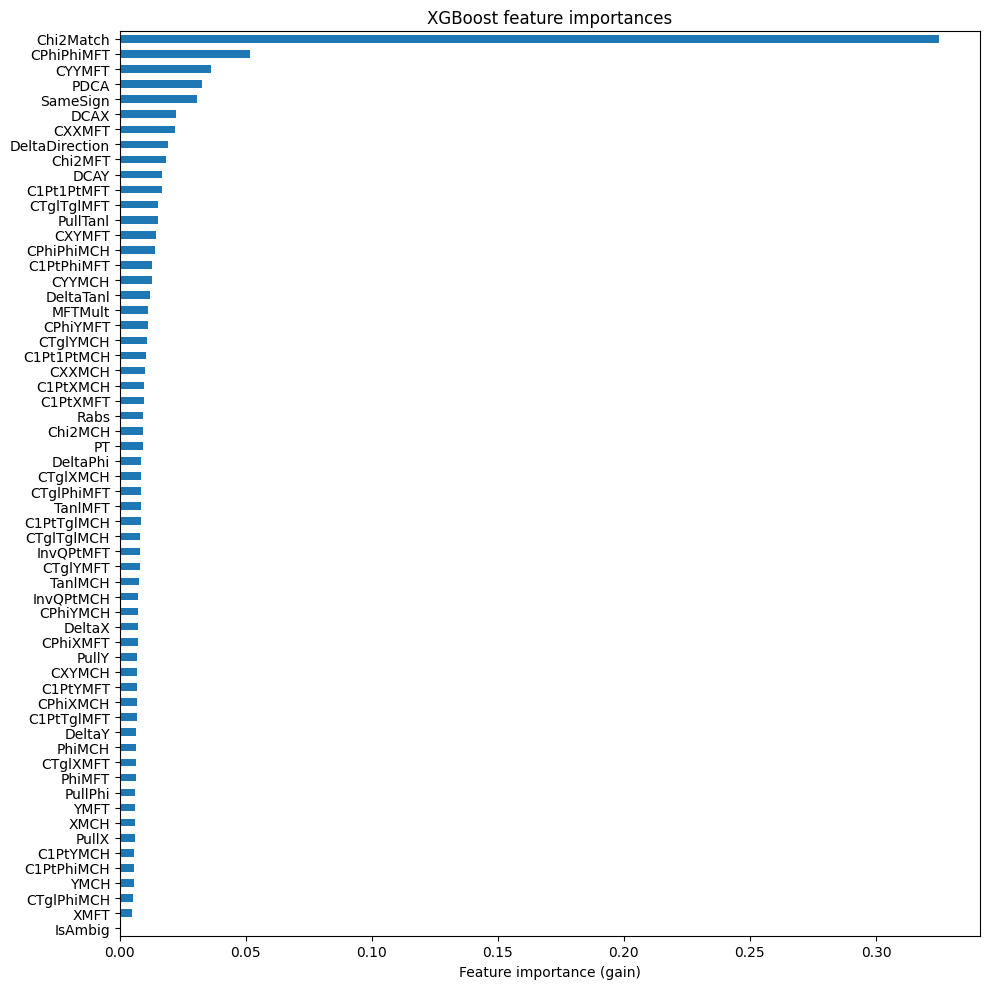

In [91]:
importances = pd.Series(
    model.feature_importances_, index=FEATURES
).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 10))
importances.plot.barh(ax=ax)
ax.set_xlabel("Feature importance (gain)")
ax.set_title("XGBoost feature importances")
plt.tight_layout()
plt.show()

## 7. Group-Level Evaluation

Metrics are computed at the **MCH track level**, not the pair level:

- **Efficiency**: fraction of tracks where the top-scored candidate is the true match  
- **Purity**: fraction of *accepted* matches that are correct (varies with threshold)  
- **MRR**: Mean Reciprocal Rank — comparable to the Ejima et al. result  
- **Purity–efficiency curve**: sweep the score threshold

In [92]:
df_test = df_test.copy()
df_test["score"] = model.predict(X_test)


def build_group_summary(df_eval: pd.DataFrame) -> pd.DataFrame:
    """
    Vectorised: for each MCH track group, find the top-scored candidate
    and the rank of the true match. Returns one row per group.
    """
    # Score rank within group (1 = highest score)
    df_eval = df_eval.copy()
    df_eval["score_rank"] = (
        df_eval.groupby(GROUP)["score"]
        .rank(ascending=False, method="first")
        .astype(int)
    )

    # Top-scored candidate per group
    top = df_eval[df_eval["score_rank"] == 1][[GROUP, "score", TARGET]].copy()
    top.columns = [GROUP, "top_score", "top_correct"]

    # Rank of the true match per group (NaN if no true match in group)
    true_match_rank = (
        df_eval[df_eval[TARGET] == 1]
        .set_index(GROUP)["score_rank"]
        .rename("true_rank")
    )

    # Whether any true match exists in the group
    has_match = df_eval.groupby(GROUP)[TARGET].max().rename("has_match")

    summary = (
        top.set_index(GROUP)
        .join(true_match_rank)
        .join(has_match)
        .reset_index()
    )
    return summary


def compute_group_metrics(summary: pd.DataFrame,
                          threshold: float) -> dict:
    """
    Given the pre-computed group summary, apply a score threshold and
    return efficiency, purity, MRR, and acceptance rate.
    """
    accepted  = summary[summary["top_score"] >= threshold]
    matchable = summary[summary["has_match"] == 1]

    efficiency = matchable["top_correct"].mean() if len(matchable) else 0.0
    purity     = accepted["top_correct"].mean()  if len(accepted)  else 0.0

    rr = 1.0 / matchable["true_rank"].dropna()
    mrr = rr.mean() if len(rr) else 0.0

    return {
        "True efficiency":       efficiency, # internally efficiency, in our nomenclature, is the fraction of matchable tracks that are correctly identified as such by the top candidate passing the threshold - True Eff
        "purity":           purity,          # internally purity, in our nomenclature, it is the fraction of accepted tracks that are correctly assigned to their true match among all accepted tracks purity
        "mrr":              mrr,
        "n_accepted":       len(accepted),
        "n_total":          len(summary),
        "acceptance_rate":  len(accepted) / len(summary) if len(summary) else 0.0,
    }


# Build summary once; reuse for all threshold sweeps
summary = build_group_summary(df_test)

# Pick a sensible default threshold: median of top-candidate scores
default_threshold = 0 #float(summary["top_score"].median())
print(f"Score range (top candidates): "
      f"[{summary['top_score'].min():.3f}, {summary['top_score'].max():.3f}]")
print(f"Default threshold (median):    {default_threshold:.3f}")

metrics = compute_group_metrics(summary, threshold=default_threshold)
print(f"\n=== Group-level metrics (threshold={default_threshold:.3f}) ===")
for k, v in metrics.items():
    print(f"  {k:20s}: {v:.4f}" if isinstance(v, float) else f"  {k:20s}: {v}")

Score range (top candidates): [-1.235, 1.143]
Default threshold (median):    0.000

=== Group-level metrics (threshold=0.000) ===
  True efficiency     : 0.7875
  purity              : 0.5773
  mrr                 : 0.8460
  n_accepted          : 724
  n_total             : 980
  acceptance_rate     : 0.7388


In [93]:
g = xgb.to_graphviz(
    model,
    num_trees=10,
    graph_attr={"dpi": "300", "size": "20,10"}
)

g.render("xgb_tree", format="png", cleanup=True)

/home/zinhle/.local/lib/python3.10/site-packages/xgboost/plotting.py:268: FutureWarning: The `num_trees` parameter is deprecated, use `tree_idx` insetad. 
  warnings.warn(


'xgb_tree.png'

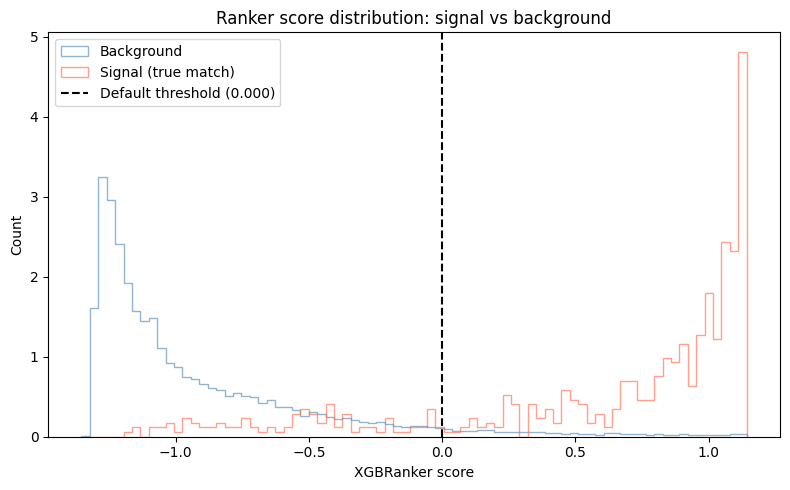

In [102]:
dense = True
sig = df_test[df_test[TARGET] == 1]["score"]
bkg = df_test[df_test[TARGET] == 0]["score"]

fig, ax = plt.subplots(figsize=(8, 5))
bins = np.linspace(df_test["score"].min(), df_test["score"].max(), 80)

ax.hist(bkg, bins=bins, density=dense, alpha=0.6, color="steelblue",histtype='step', label="Background")
ax.hist(sig, bins=bins, density=dense, alpha=0.6, color="tomato",histtype='step',    label="Signal (true match)")

ax.axvline(default_threshold, color="black", linestyle="--", lw=1.5,
           label=f"Default threshold ({default_threshold:.3f})")

ax.set_xlabel("XGBRanker score")
ax.set_ylabel("Count")
ax.set_title("Ranker score distribution: signal vs background")
ax.legend()
plt.tight_layout()
plt.show()

## 8. Purity–Efficiency Curve

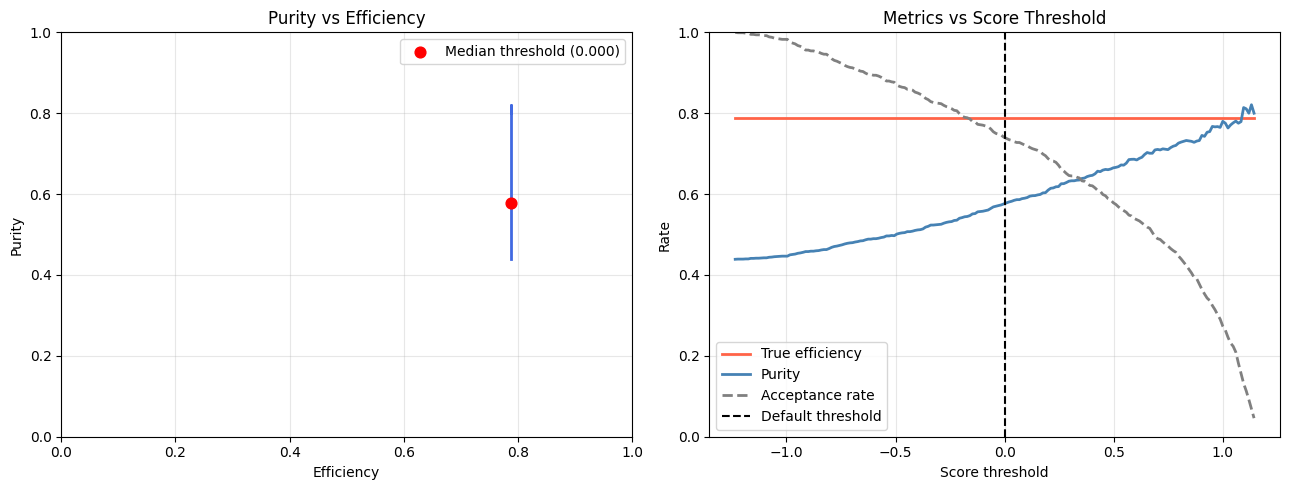

MRR (no threshold): 0.8460


In [103]:
# Sweep over the actual score range of top candidates
score_min = summary["top_score"].min()
score_max = summary["top_score"].max()
thresholds = np.linspace(score_min, score_max, 200)

records = [compute_group_metrics(summary, t) | {"threshold": t} for t in thresholds]
curve   = pd.DataFrame(records)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: purity vs efficiency
ax = axes[0]
ax.plot(curve["True efficiency"], curve["purity"], lw=2, color="royalblue")
m_def = compute_group_metrics(summary, default_threshold)
ax.scatter(m_def["True efficiency"], m_def["purity"],
           color="red", zorder=5, s=60,
           label=f"Median threshold ({default_threshold:.3f})")
ax.set_xlabel("Efficiency")
ax.set_ylabel("Purity")
ax.set_title("Purity vs Efficiency")
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.grid(True, alpha=0.3)
ax.legend()

# Right: both vs threshold
ax = axes[1]
ax.plot(curve["threshold"], curve["True efficiency"],
        lw=2, color="tomato",     label="True efficiency")
ax.plot(curve["threshold"], curve["purity"],
        lw=2, color="steelblue",  label="Purity")
ax.plot(curve["threshold"], curve["acceptance_rate"],
        lw=2, color="grey", linestyle="--", label="Acceptance rate")
ax.axvline(default_threshold, color="black", linestyle="--", lw=1.5,
           label=f"Default threshold")
ax.set_xlabel("Score threshold")
ax.set_ylabel("Rate")
ax.set_title("Metrics vs Score Threshold")
ax.set_ylim(0, 1)
ax.grid(True, alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()

print(f"MRR (no threshold): {compute_group_metrics(summary, score_min)['mrr']:.4f}")

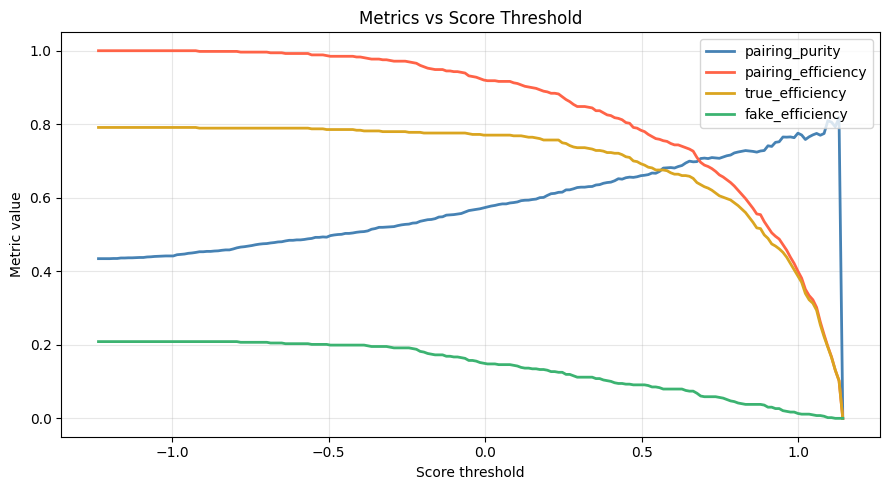

In [104]:

def sweep_threshold_plot(df_eval, summary, compute_metrics_fn, 
                         score_col="top_score", n_steps=200, title="Metrics vs Threshold"):
    """
    Sweeps a threshold over the range of top candidate scores,
    calls compute_metrics_fn(df_eval, summary, threshold) at each step,
    and plots the 4 returned metrics in different colours.
    
    compute_metrics_fn should return a tuple of (metric1, metric2, metric3, metric4)
    and accept (df_eval, summary, threshold) as arguments.
    Adjust the signature to match your actual function.
    """
    score_min = summary[score_col].min()
    score_max = summary[score_col].max()
    thresholds = np.linspace(score_min, score_max, n_steps)
    
    results = [compute_metrics_fn(df_eval, t) for t in thresholds]
    m1, m2, m3, m4 = zip(*results)
    
    colours = ["steelblue", "tomato", "goldenrod", "mediumseagreen"]
    # Update these labels to match what your function actually returns
    labels  = ["pairing_purity", "pairing_efficiency", "true_efficiency", "fake_efficiency"]
    metrics = [m1, m2, m3, m4]
    
    fig, ax = plt.subplots(figsize=(9, 5))
    for vals, label, colour in zip(metrics, labels, colours):
        ax.plot(thresholds, vals, lw=2, label=label, color=colour)
    
    ax.set_xlabel("Score threshold")
    ax.set_ylabel("Metric value")
    ax.set_title(title)
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

sweep_threshold_plot(df_test, summary, inhousemetrics, title="Metrics vs Score Threshold")

## Misranking Analysis --- to be HEAVILY modified - include those with no match
We label each MCH track group as **correct** (true match is top-ranked) or **misranked** (true match exists but was not top-ranked).  
Groups with no true match among candidates are excluded from this analysis.

In [105]:
# Build full outcome labels across all groups
full_analysis = summary.copy()
full_analysis["outcome"] = np.where(
    full_analysis["has_match"] == 0, "No match",
    np.where(full_analysis["top_correct"] == 1, "Correct", "Misranked")
)

counts = full_analysis["outcome"].value_counts()
total  = len(full_analysis)
for outcome in ["Correct", "Misranked", "No match"]:
    n = counts.get(outcome, 0)
    print(f"{outcome:12s}: {n:,}  ({100*n/total:.2f}%)")

# Restrict to groups with a true match for the margin/scatter/kinematic plots
analysis = full_analysis[full_analysis["has_match"] == 1].copy()

# True match score per group
true_scores = (
    df_test[df_test[TARGET] == 1]
    .groupby(GROUP)["score"].first()
    .rename("true_score")
)
# Second-highest score per group
second_scores = (
    df_test.groupby(GROUP)["score"]
    .apply(lambda s: s.nlargest(2).iloc[-1])
    .rename("second_score")
)

analysis = analysis.set_index(GROUP).join(true_scores).join(second_scores).reset_index()
analysis["score_margin"] = analysis["top_score"] - analysis["second_score"]

Correct     : 430  (43.88%)
Misranked   : 116  (11.84%)
No match    : 434  (44.29%)


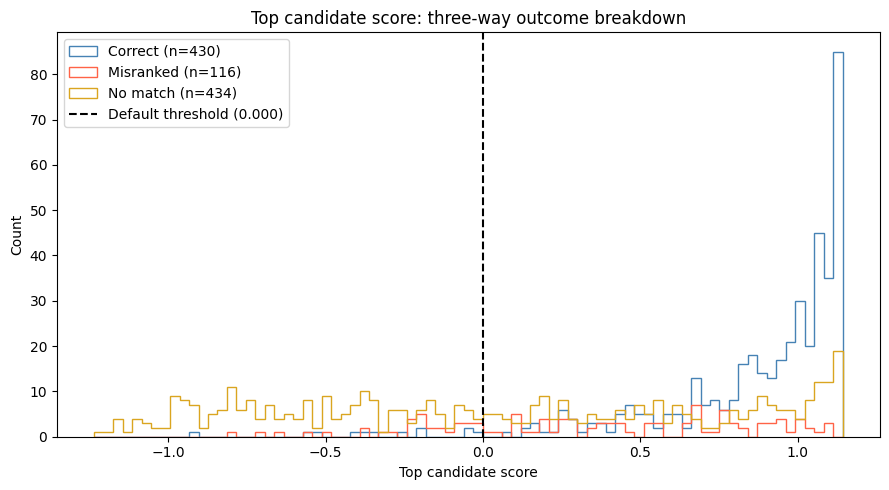

In [106]:
# --- Plot 1: Three-way top candidate score distribution ---
# Key diagnostic: can the threshold separate no-match groups from real matches?
palette = {"Correct": "steelblue", "Misranked": "tomato", "No match": "goldenrod"}
score_min_all = full_analysis["top_score"].min()
score_max_all = full_analysis["top_score"].max()
bins = np.linspace(score_min_all, score_max_all, 80)

fig, ax = plt.subplots(figsize=(9, 5))
for outcome in ["Correct", "Misranked", "No match"]:
    sub = full_analysis[full_analysis["outcome"] == outcome]["top_score"]
    ax.hist(sub, bins=bins, density=False,histtype='step',
            color=palette[outcome], label=f"{outcome} (n={len(sub):,})")

ax.axvline(default_threshold, color="black", linestyle="--", lw=1.5,
           label=f"Default threshold ({default_threshold:.3f})")
ax.set_xlabel("Top candidate score")
ax.set_ylabel("Count")
ax.set_title("Top candidate score: three-way outcome breakdown")
ax.legend()
plt.tight_layout()
plt.show()

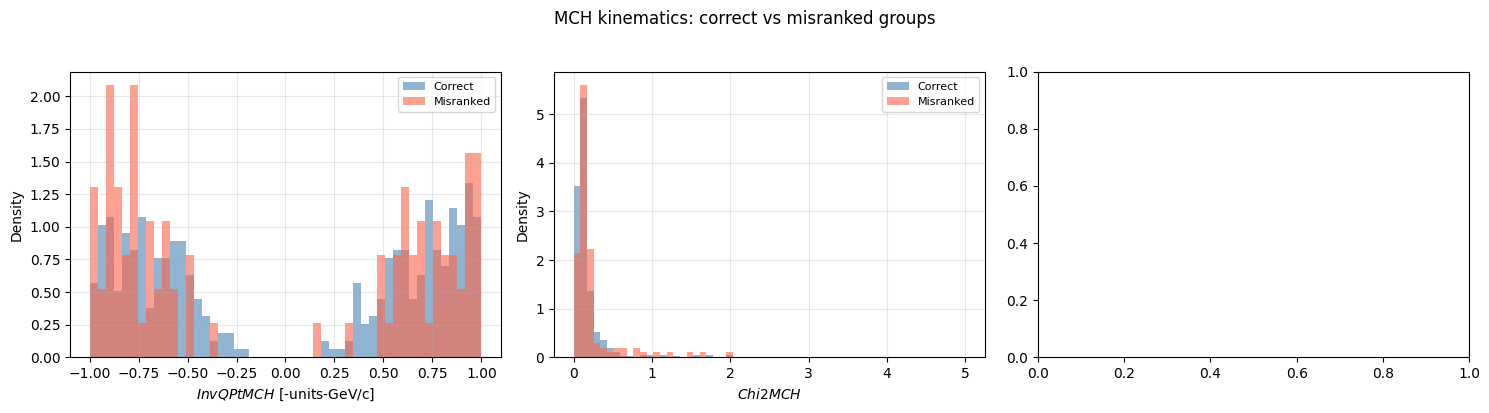

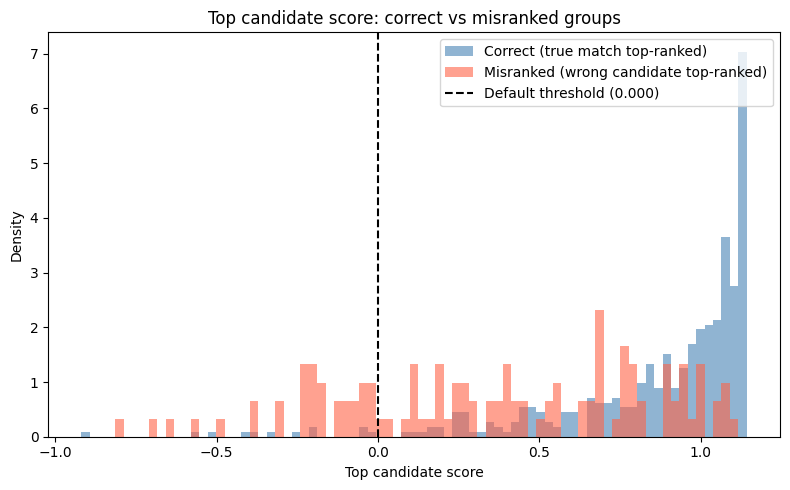

In [107]:
# --- Plot 1: Top candidate score split by outcome ---
correct_scores   = analysis[analysis["outcome"] == "Correct"]["top_score"]
misranked_scores = analysis[analysis["outcome"] == "Misranked"]["top_score"]
# --- Plot 4: Kinematic distributions of the MCH track --- correct vs misranked
# Reveals if failures are concentrated in specific regions of phase space
true_kinematics = (
    df_test[df_test[TARGET] == 1]
    [[GROUP, "InvQPtMCH", "Chi2MCH"]]
    .drop_duplicates(subset=GROUP)
    .set_index(GROUP)
)
analysis_kin = analysis.set_index(GROUP).join(true_kinematics).reset_index()

kin_vars = {
    "InvQPtMCH":   (r"$InvQPtMCH$ [-units-GeV/c]",  np.linspace(-1,  1, 50)),
    "Chi2MCH": (r"$Chi2MCH$",        np.linspace(0, 5, 60)),
}

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (var, (label, bins)) in zip(axes, kin_vars.items()):
    for outcome, colour in [("Correct", "steelblue"), ("Misranked", "tomato")]:
        sub = analysis_kin[analysis_kin["outcome"] == outcome]
        ax.hist(sub[var].dropna(), bins=bins, density=True,
                alpha=0.6, color=colour, label=outcome)
    ax.set_xlabel(label)
    ax.set_ylabel("Density")
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

fig.suptitle("MCH kinematics: correct vs misranked groups", y=1.02)
plt.tight_layout()
plt.show()
bins = np.linspace(analysis["top_score"].min(), analysis["top_score"].max(), 80)

fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(correct_scores,   bins=bins, density=True, alpha=0.6,
        color="steelblue", label="Correct (true match top-ranked)")
ax.hist(misranked_scores, bins=bins, density=True, alpha=0.6,
        color="tomato",    label="Misranked (wrong candidate top-ranked)")
ax.axvline(default_threshold, color="black", linestyle="--", lw=1.5,
           label=f"Default threshold ({default_threshold:.3f})")
ax.set_xlabel("Top candidate score")
ax.set_ylabel("Density")
ax.set_title("Top candidate score: correct vs misranked groups")
ax.legend()
plt.tight_layout()
plt.show()

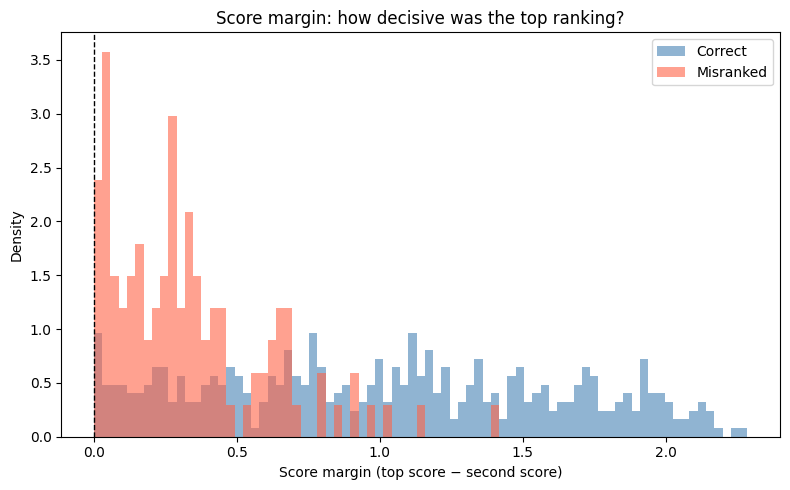

In [108]:
# --- Plot 2: Score margin (top - second) split by outcome ---
# Large margin = confident decision; near-zero = top two were almost tied
bins_m = np.linspace(analysis["score_margin"].min(), analysis["score_margin"].max(), 80)

fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(analysis[analysis["outcome"] == "Correct"]["score_margin"],
        bins=bins_m, density=True, alpha=0.6,
        color="steelblue", label="Correct")
ax.hist(analysis[analysis["outcome"] == "Misranked"]["score_margin"],
        bins=bins_m, density=True, alpha=0.6,
        color="tomato",    label="Misranked")
ax.axvline(0, color="black", linestyle="--", lw=1)
ax.set_xlabel("Score margin (top score − second score)")
ax.set_ylabel("Density")
ax.set_title("Score margin: how decisive was the top ranking?")
ax.legend()
plt.tight_layout()
plt.show()

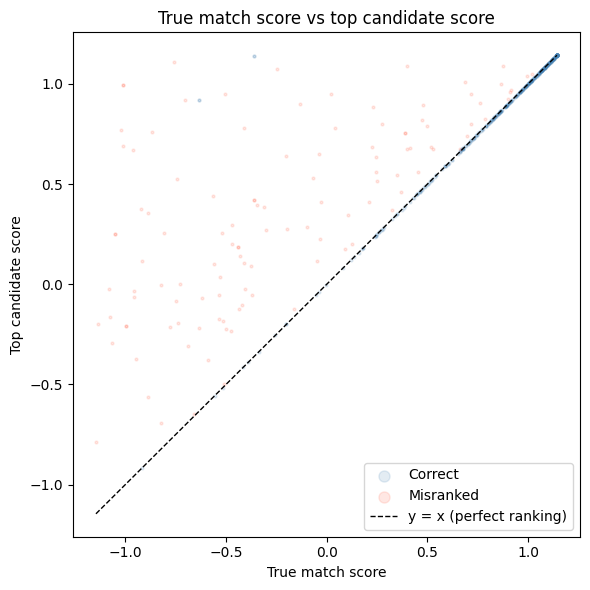

In [109]:
# --- Plot 3: True match score vs top candidate score (scatter) ---
# Points on the diagonal = true match was top-ranked
# Points below diagonal  = a wrong candidate outscored the true match
fig, ax = plt.subplots(figsize=(6, 6))

for outcome, colour in [("Correct", "steelblue"), ("Misranked", "tomato")]:
    sub = analysis[analysis["outcome"] == outcome]
    ax.scatter(sub["true_score"], sub["top_score"],
               alpha=0.15, s=4, color=colour, label=outcome, rasterized=True)

lims = [analysis[["true_score", "top_score"]].min().min(),
        analysis[["true_score", "top_score"]].max().max()]
ax.plot(lims, lims, "k--", lw=1, label="y = x (perfect ranking)")
ax.set_xlabel("True match score")
ax.set_ylabel("Top candidate score")
ax.set_title("True match score vs top candidate score")
ax.legend(markerscale=4)
plt.tight_layout()
plt.show()